In [114]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import defaultdict

## Tokyo 2018 PT Master

In [2]:
pt = pd.read_csv("/mnt/large/data/PersonTrip/関東都市圏/第６回（H３０）/01マスターデータ/MS2611.csv", encoding='cp932')
pt

,レコード区分,回収分類,バッチ番号,整理番号：市区町村,整理番号：ロット番号,整理番号：世帯ＳＱ,世帯人数／5歳未満含む,世帯人数／5歳未満除く,回収個人票数,現住所：完全桁数,...,トリップ時間（分）,滞在時間（分）,マストラ乗車：代表交通手段,マストラ乗車：駅コード（施設）,マストラ乗車：駅地点（ゾーン）,マストラ乗車：端末手段,マストラ降車：代表交通手段,マストラ降車：駅コード（施設）,マストラ降車：駅地点（ゾーン）,マストラ降車：端末手段
0,1,1,1,3108,1,18,2,2,2,7,...,9999.0,9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,1,3108,1,18,2,2,2,7,...,9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,1,3108,1,18,2,2,2,7,...,30.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1,1,3108,1,18,2,2,2,7,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,1,3108,1,58,2,2,2,7,...,20.0,9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693078,2,2,999,9153,6,1731,2,99,1,7,...,49.0,NaN,5.0,1809.0,2914319.0,1.0,5.0,1709.0,810006.0,1.0
693079,1,2,999,9153,6,1753,2,99,1,7,...,30.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
693080,2,2,999,9153,6,1753,2,99,1,7,...,30.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
693081,2,2,999,9153,6,1753,2,99,1,7,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Assign individual files by demographics

In [7]:
path = '/mnt/large/data/PseudoPFLOW/ver2.0/Tokyo_PT_2018/'

for pid, person in pt.groupby(['整理番号：市区町村', '整理番号：ロット番号', '整理番号：世帯ＳＱ', '個人番号']):

    uid = f'{pid[0]:04}{pid[1]}{pid[2]:05}{pid[2]:02}'
   
    gender, age, occupation = person['性別'].iloc[0], person['年齢'].iloc[0], person['就業（形態・状況）'].iloc[0]
    
    directory = ''

    if occupation == 7:
        directory = 'student1/' if age < 19 else 'student2/'
    elif occupation in [2, 3, 4, 5]:
        directory = 'labor_male/' if gender == 1 else 'labor_female/'
    else:
        if age > 65:
            directory = 'nolabor_male_senior/' if gender == 1 else 'nolabor_female_senior/'
        else:
            directory = 'nolabor_male/' if gender == 1 else 'nolabor_female/'
    
    # print(directory, uid)
    if directory: 
        person.to_csv(f'{path}{directory}{uid}.csv', index=False)

### Temporal (15min) Activity Interpolation 

In [8]:
def survey_time_to_datetime(hour, minute, am_pm):
    if pd.isna(hour) or pd.isna(minute) or hour == 99 or minute == 99:
        return None
    hour, minute = int(hour), int(minute)
    if am_pm == 2 and hour < 12:
        hour += 12
    return datetime(2024, 1, 1, hour, minute)

# Define the mapping from activity numbers to their corresponding codes
activity_mapping = {str(key): value for key, value in {
    '1': '002', '2': '003', '3': '100', '4': '100', '5': '200', '6': '400',
    '7': '300', '8': '300', '9': '400', '10': '400', '11': '400', '12': '400',
    '13': '400', '14': '400', '15': '400', '16': '500', '17': '500', '18': '500',
    '19': '001', '20': '400', '0': '000'
}.items()}

In [9]:
def adjust_activity_for_overlapping_intervals_with_mapping(dataset):
    precise_activity_intervals = defaultdict(lambda: defaultdict(int))
    skip_file = False

    for _, trip in dataset.iterrows():
        try:
            purpose = str(int(trip['移動の目的'])) if not pd.isna(trip['移動の目的']) and trip['移動の目的'] != 99 else "0"
            start_time = survey_time_to_datetime(trip['出発時刻：時'], trip['出発時刻：分'], trip['出発時刻：午前・午後'])
            end_time = survey_time_to_datetime(trip['到着時刻：時'], trip['到着時刻：分'], trip['到着時刻：午前・午後'])

            if start_time and end_time:
                current_time = start_time - timedelta(minutes=start_time.minute % 15)
                while current_time < end_time:
                    interval_end = current_time + timedelta(minutes=15)
                    overlap_start = max(current_time, start_time)
                    overlap_end = min(interval_end, end_time)
                    overlap_duration = (overlap_end - overlap_start).total_seconds() / 60
                    if overlap_duration > 0:
                        precise_activity_intervals[current_time.strftime('%H:%M')][purpose] += overlap_duration
                    current_time += timedelta(minutes=15)
        except KeyError:
            print(f"KeyError encountered in file. Skipping file: {file_path}")
            return None

    resolved_schedule = {}
    for time_point, activities in precise_activity_intervals.items():
        main_activity = max(activities, key=lambda k: (activities[k], k != '0')) if activities else '0'
        resolved_schedule[time_point] = activity_mapping.get(main_activity, '000')

    for h in range(24):
        for m in range(0, 60, 15):
            time_slot = f"{h:02d}:{m:02d}"
            if time_slot not in resolved_schedule:
                resolved_schedule[time_slot] = '000'
                
    if resolved_schedule['00:00'] == '000':
        resolved_schedule['00:00'] = '001'

    return dict(sorted(resolved_schedule.items(), key=lambda x: datetime.strptime(x[0], '%H:%M')))

In [85]:
adjust_activity_for_overlapping_intervals_with_mapping(new_data)

{'00:00': '001',
 '00:15': '000',
 '00:30': '000',
 '00:45': '000',
 '01:00': '000',
 '01:15': '000',
 '01:30': '000',
 '01:45': '000',
 '02:00': '000',
 '02:15': '000',
 '02:30': '000',
 '02:45': '000',
 '03:00': '000',
 '03:15': '000',
 '03:30': '000',
 '03:45': '000',
 '04:00': '000',
 '04:15': '000',
 '04:30': '000',
 '04:45': '000',
 '05:00': '000',
 '05:15': '000',
 '05:30': '000',
 '05:45': '000',
 '06:00': '002',
 '06:15': '002',
 '06:30': '500',
 '06:45': '500',
 '07:00': '500',
 '07:15': '500',
 '07:30': '500',
 '07:45': '500',
 '08:00': '500',
 '08:15': '500',
 '08:30': '500',
 '08:45': '500',
 '09:00': '500',
 '09:15': '500',
 '09:30': '500',
 '09:45': '002',
 '10:00': '002',
 '10:15': '500',
 '10:30': '000',
 '10:45': '500',
 '11:00': '002',
 '11:15': '000',
 '11:30': '500',
 '11:45': '500',
 '12:00': '500',
 '12:15': '500',
 '12:30': '500',
 '12:45': '500',
 '13:00': '500',
 '13:15': '002',
 '13:30': '500',
 '13:45': '500',
 '14:00': '500',
 '14:15': '500',
 '14:30': '200

In [10]:
source_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Tokyo_PT_2018/"
target_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Markov/"

# Walk through the source directory
for root, dirs, files in os.walk(source_base_path):
    for file in files:
        if file == '.DS_Store':
            continue
        try: 
            file_path = os.path.join(root, file)
            data = pd.read_csv(file_path)
            final_schedule_with_mapping = adjust_activity_for_overlapping_intervals_with_mapping(data)

            if final_schedule_with_mapping is None:
                print(f"Skipped file due to '99': {file_path}")
                continue

            relative_path = os.path.relpath(root, source_base_path)
            target_dir = os.path.join(target_base_path, relative_path)
            if not os.path.exists(target_dir):
                os.makedirs(target_dir)
            target_file_path = os.path.join(target_dir, file)

            # Convert the schedule to a DataFrame and save as CSV
            pd.DataFrame.from_dict(final_schedule_with_mapping, orient='index', columns=['Activity']).to_csv(target_file_path, index_label='Time')
        except Exception as e:
            print(f"An error occurred while processing file {file_path}: {e}")
print("Processing completed.")

Processing completed.


### Time-dependent Markov Chain

In [28]:
def save_markov_chain(transition_probabilities, time_slots, states, output_file_path):
    with open(output_file_path, 'w') as f:
        for step, time_slot in enumerate(time_slots):  
            line = f"{step:03d},"
            for s1 in states[1:]:
                line = line + s1 + ' '
                for s2 in states:
                    line = line + s2 + ' ' + str(transition_probabilities[time_slot][states.index(s1)][states.index(s2)]) + ' '
                line += ','
            f.write(line.strip(' ,')+'\n')

In [30]:
states = ['000', '001', '002', '003', '100', '200', '300', '400', '500']
state_indices = {state: idx for idx, state in enumerate(states)}  
time_steps = [f"{h:02d}:{m:02d}" for h in range(24) for m in range(0, 60, 15)]

source_folder = '/mnt/large/data/PseudoPFLOW/ver2.0/Markov/'
target_folder = '/mnt/large/data/PseudoPFLOW/Processing/markov/'
dirs = ['student2', 'nolabor_male_senior', 'nolabor_female', 'nolabor_male', 'labor_male', 'nolabor_female_senior', 'student1', 'labor_female']

for folder in dirs:
    transition_counts_per_time_step = {time_step: np.zeros((len(states), len(states))) for time_step in time_steps}
    folder_path = os.path.join(source_folder, folder)
    
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):
            data = pd.read_csv(file_path, dtype={'Time': str, 'Activity': str})
            data.sort_values(by='Time', inplace=True)

            previous_state = None
            data_length = len(data) - 1
            for i in range(data_length):
                current_state, next_state, time_step = data.iloc[i]['Activity'], data.iloc[i + 1]['Activity'], data.iloc[i]['Time']
                if current_state != '000':
                    previous_state = current_state

                if previous_state in state_indices and next_state in state_indices:
                    if previous_state == next_state:
                        next_state = '000'
                    previous_index, next_index = state_indices[previous_state], state_indices[next_state]
                    transition_counts_per_time_step[time_step][previous_index, next_index] += 1

    transition_probabilities_per_time_step = {}
    for time_step, counts in transition_counts_per_time_step.items():
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1 
        probabilities = counts / row_sums
        transition_probabilities_per_time_step[time_step] = probabilities

    output_path = os.path.join(source_folder, f'tokyo2018_trip_{folder}_prob.csv')
    save_markov_chain(transition_probabilities_per_time_step, time_steps, states, output_path)

### Multi-process

In [58]:
from multiprocessing import Pool

In [59]:
def process_file(args):
    file_path, all_states, time_slots = args
    transition_counts = {time_slot: {state: {next_state: 0 for next_state in all_states} for state in all_states} for time_slot in time_slots}

    data = pd.read_csv(file_path, dtype={'Time': str, 'Activity': str})
    data.sort_values(by='Time', inplace=True)

    for i in range(len(data) - 1):
        current_time = data.iloc[i]['Time']
        next_time = data.iloc[i + 1]['Time']
        current_state = data.iloc[i]['Activity']
        next_state = data.iloc[i + 1]['Activity']

        time_slot = current_time[:5]
        if time_slot in transition_counts:
            transition_counts[time_slot][current_state][next_state] += 1

    return transition_counts

def merge_transition_counts(counts_list):
    merged_counts = counts_list[0]
    for counts in counts_list[1:]:
        for time_slot, state_counts in counts.items():
            for state, next_state_counts in state_counts.items():
                for next_state, count in next_state_counts.items():
                    merged_counts[time_slot][state][next_state] += count
    return merged_counts

def calculate_transition_probabilities(transition_counts, all_states, time_slots):
    transition_probabilities = {}
    for time_slot in time_slots:
        probabilities = np.zeros((len(all_states), len(all_states)))
        for i, state in enumerate(all_states):
            total_transitions = sum(transition_counts[time_slot][state].values())
            if total_transitions > 0:
                for j, next_state in enumerate(all_states):
                    probabilities[i, j] = transition_counts[time_slot][state][next_state] / total_transitions
            else:
                probabilities[i, i] = 1.0
        transition_probabilities[time_slot] = probabilities
    return transition_probabilities

In [60]:
all_states = ["000", "001", "002", "003", "100", "200", "300", "400", "500"]
time_slots = [f"{h:02d}:{m:02d}" for h in range(24) for m in range(0, 60, 15)]

source_folder = '/Users/pang/Data/PseudoPFLOW/ver2.0/Markov/student2'
file_paths = [os.path.join(root, f) for root, _, files in os.walk(source_folder) for f in files]
file_args = [(path, all_states, time_slots) for path in file_paths]

with Pool(processes=os.cpu_count()) as pool:
    results = pool.map(process_file, file_args)

merged_counts = merge_transition_counts(results)
transition_probabilities = calculate_transition_probabilities(merged_counts, all_states, time_slots)

Process SpawnPoolWorker-15:
Process SpawnPoolWorker-14:
Process SpawnPoolWorker-13:
Process SpawnPoolWorker-16:
Process SpawnPoolWorker-17:
Process SpawnPoolWorker-18:
Traceback (most recent call last):
  File "/Users/pang/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/Users/pang/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/pang/opt/anaconda3/lib/python3.9/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/Users/pang/opt/anaconda3/lib/python3.9/multiprocessing/queues.py", line 367, in get
    return _ForkingPickler.loads(res)
Traceback (most recent call last):
  File "/Users/pang/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
AttributeError: Can't get attribute 'process_file' on <module '__main__' (buil

KeyboardInterrupt: 

In [37]:
transition_counts_per_time_step 

{'00:00': array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 '00:15': array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 '00:30': array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
   

In [ ]:
{-1=57236, 1=174488, 2=631053, 99=123208, 3=15154, 4=59386, 5=6056, 6=5117, 7=46387, 8=83, 9=351, 10=3533, 11=43195, 13=19, 15=32901}
{-1=57262, 1=174485, 2=692879, 3=34197, 99=1629, 4=158845, 5=21583, 6=3516, 7=29908, 8=116, 9=300, 10=551, 11=17891, 13=74, 15=4931}

In [ ]:
-1=15456, 1=104564, 2=646799, 3=44305, 99=13251, 4=188359, 5=34243, 6=14396, 7=64205, 8=265, 9=811, 10=3967, 11=47271, 13=420, 15=19855

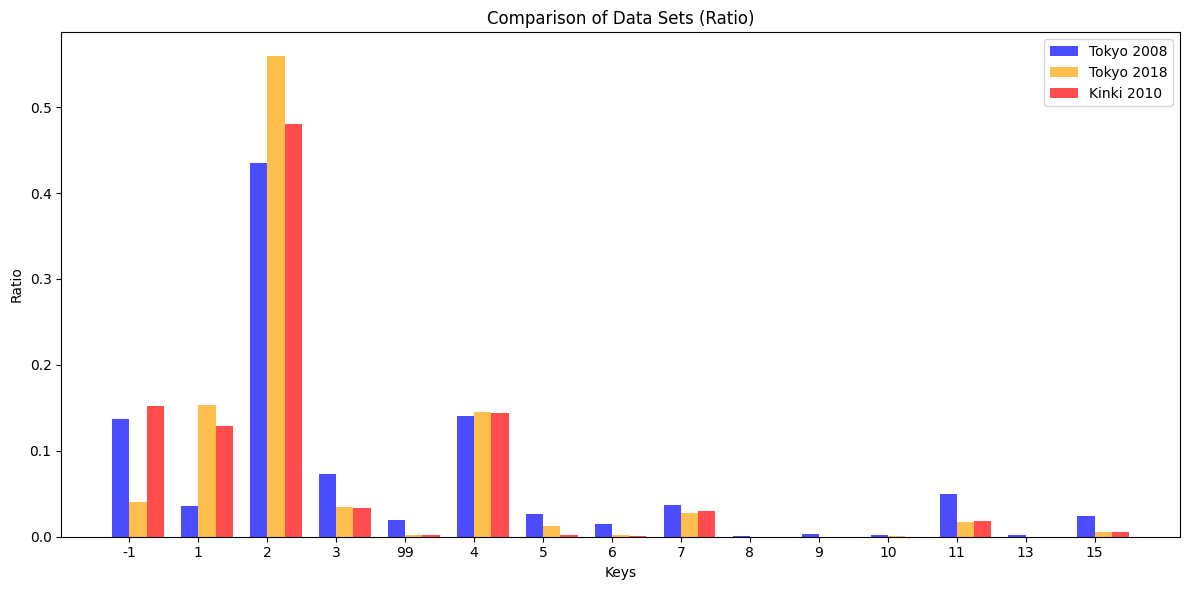

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# data1 = {-1:57262, 1:174485, 2:692879, 3:34197, 99:1629, 4:158845, 5:21583, 6:3516, 7:29908, 8:116, 9:300, 10:551, 11:17891, 13:74, 15:4931}
# data1 = {-1: 15456, 1: 104564, 2: 646799, 3: 44305, 99: 13251, 4: 188359, 5: 34243, 6: 14396, 7: 64205, 8: 265, 9: 811, 10: 3967, 11: 47271, 13: 420, 15: 19855}
data1 = {-1:424707, 1:110688, 2:1350333, 3:226050, 99:61161, 4:434705, 5:83037, 6:46573, 7:114020, 8:2690, 9:8770, 10:6315, 11:154007, 13:4536, 15:76218}
data2 =  {-1:69478, 1:264420, 2:961343, 3:59186, 99:2915, 4:249054, 5:22232, 6:4283, 7:46535, 8:231, 9:362, 10:613, 11:29976, 13:127, 15:8659}
data3 = {-1: 160808, 1: 135597, 2: 506335, 3: 35670, 99: 1942, 4: 151323, 5: 2714, 6: 1437, 7: 31433, 8: 122, 9: 119, 10: 115, 11: 19673, 13: 61, 15: 5845}

# Extract keys and corresponding values for each dataset
keys = list(data1.keys())
values1 = np.array([data1[key] for key in keys])
values2 = np.array([data2[key] for key in keys])
values3 = np.array([data3[key] for key in keys])

# Normalize the values to get proportions
values1_ratio = values1 / np.sum(values1)
values2_ratio = values2 / np.sum(values2)
values3_ratio = values3 / np.sum(values3)

# Plotting
bar_width = 0.25
index = np.arange(len(keys))

plt.figure(figsize=(12, 6))

plt.bar(index, values1_ratio, bar_width, label='Tokyo 2008', color='blue', alpha=0.7)
plt.bar(index + bar_width, values2_ratio, bar_width, label='Tokyo 2018', color='orange', alpha=0.7)
plt.bar(index + 2 * bar_width, values3_ratio, bar_width, label='Kinki 2010', color='red', alpha=0.7)

plt.xlabel('Keys')
plt.ylabel('Ratio')
plt.title('Comparison of Data Sets (Ratio)')
plt.xticks(index + bar_width / 2, keys)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
sum(data1.values()), sum(data2.values())

(1198167, 1198167)

In [ ]:
tokyo2018: {-1=287907, 1=888135, 2=3503401, 3=176508, 99=8616, 4=809519, 5=107788, 6=17313, 7=153081, 8=700, 9=1416, 10=2698, 11=90863, 13=402, 15=25450}
tokyo2008: {-1=77256, 1=532062, 2=3270502, 3=226680, 99=66809, 4=963305, 5=168842, 6=71138, 7=327053, 8=1219, 9=4041, 10=19790, 11=240292, 13=1966, 15=102437}

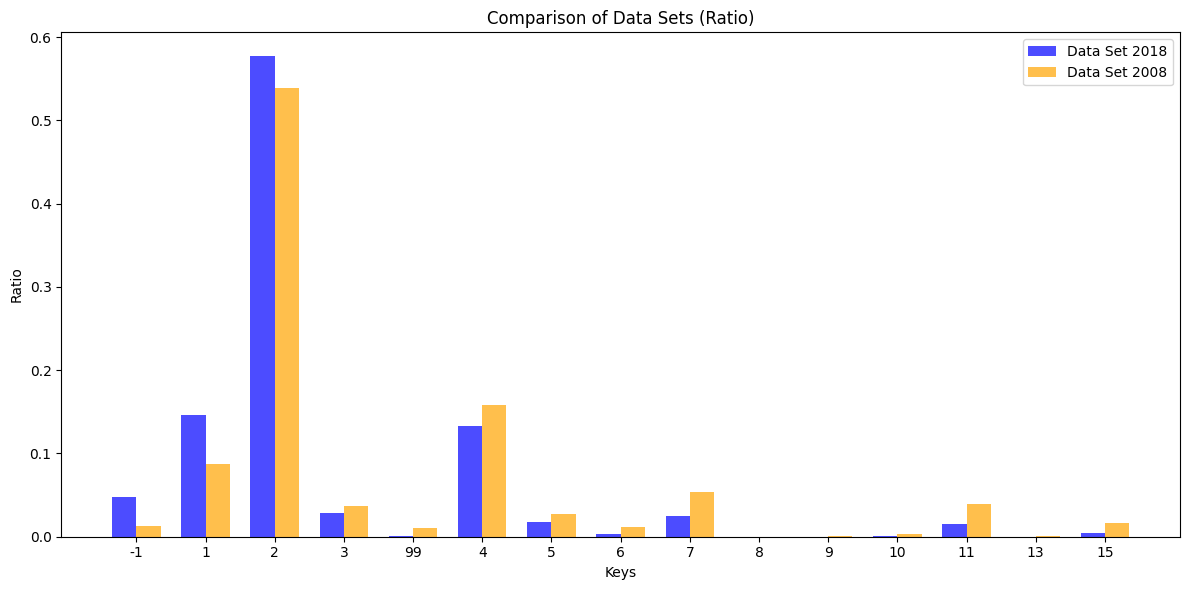

In [33]:
import matplotlib.pyplot as plt
import numpy as np

data1= {-1:287907, 1:888135, 2:3503401, 3:176508, 99:8616, 4:809519, 5:107788, 6:17313, 7:153081, 8:700, 9:1416, 10:2698, 11:90863, 13:402, 15:25450}
data2= {-1:77256, 1:532062, 2:3270502, 3:226680, 99:66809, 4:963305, 5:168842, 6:71138, 7:327053, 8:1219, 9:4041, 10:19790, 11:240292, 13:1966, 15:102437}

# Extract keys and corresponding values for each dataset
keys = list(data1.keys())
values1 = np.array([data1[key] for key in keys])
values2 = np.array([data2[key] for key in keys])

# Normalize the values to get proportions
values1_ratio = values1 / np.sum(values1)
values2_ratio = values2 / np.sum(values2)

# Plotting
bar_width = 0.35
index = np.arange(len(keys))

plt.figure(figsize=(12, 6))

plt.bar(index, values1_ratio, bar_width, label='Data Set 2018', color='blue', alpha=0.7)
plt.bar(index + bar_width, values2_ratio, bar_width, label='Data Set 2008', color='orange', alpha=0.7)

plt.xlabel('Keys')
plt.ylabel('Ratio')
plt.title('Comparison of Data Sets (Ratio)')
plt.xticks(index + bar_width / 2, keys)
plt.legend()

plt.tight_layout()
plt.show()

## Kinki 2010 PT Master

In [19]:
trip = pd.read_csv('/mnt/large/data/PersonTrip/近畿都市圏/01_マスターデータ/第５回（平成２２年）調査/第５回（平日）_trip.csv')
trip

,cities_code,household_person_no,trip_no,frequency,dep_pre_code,dep_zone_code,dep_cities_code,dep_pt_code,dep_pt_Mcode,dep_pt_Lcode,...,off_f_pt_Lcode,off_feeder_transport,off_feeder_ticket,move_dist,ptzone_dist,transport_div_rep_a,transport_div_rep_i,expansion_factor,correct_coefficient,magnification_factor_corrected
0,25201,2000101,1,NaN,1,5200242,25201,11110,111,11,...,NaN,NaN,NaN,9.0,50.0,NaN,NaN,36.0,1012.0,36.0
1,25201,2000101,2,NaN,2,5200243,25201,11110,111,11,...,NaN,NaN,NaN,9.0,50.0,NaN,NaN,36.0,1012.0,36.0
2,25201,3000101,1,NaN,1,5200846,25201,11140,111,11,...,NaN,NaN,NaN,30.0,50.0,NaN,NaN,17.0,1012.0,17.0
3,25201,3000101,2,NaN,3,5200055,25201,11130,111,11,...,NaN,NaN,NaN,30.0,50.0,NaN,NaN,17.0,1012.0,18.0
4,25201,3000102,1,NaN,1,5200846,25201,11140,111,11,...,NaN,NaN,NaN,5.0,50.0,NaN,NaN,20.0,1012.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942383,27123,288407025402,6,NaN,3,5320024,27123,51410,514,51,...,NaN,NaN,NaN,8.0,50.0,NaN,NaN,1.0,1012.0,1.0
2942384,27123,288407025802,1,NaN,1,5320025,27123,51410,514,51,...,NaN,NaN,NaN,5.0,50.0,NaN,NaN,1.0,1012.0,1.0
2942385,27123,288407025802,2,NaN,3,5320025,27123,51410,514,51,...,NaN,NaN,NaN,33.0,23.0,NaN,NaN,1.0,1012.0,1.0
2942386,27123,288407025802,3,NaN,2,5310062,27127,51130,511,51,...,51.0,99.0,NaN,47.0,65.0,10.0,99.0,1.0,1347.0,1.0


In [11]:
face = pd.read_csv('/mnt/large/data/PersonTrip/近畿都市圏/01_マスターデータ/第５回（平成２２年）調査/第５回（平日）_face.csv')
face

,cities_code,household_person_no,trip_end_no,survey_month,survey_day,address_zone_code,address_cities_code,address_pt_code,address_pt_Mcode,address_pt_Lcode,...,wagon_cnt,bus,motorcycles_cnt,scooter_cnt,bicycle_cnt,person_cnt,under5_person_cnt,in_area_flg_3,in_area_flg_4,expansion_factor2
0,25201,1000101,0,11.0,9.0,5200062,25201,11130,111,11,...,0,0,0,0,0,1,99,1.0,1.0,25
1,25201,2000101,2,11.0,9.0,5200242,25201,11110,111,11,...,0,0,0,0,2,1,0,1.0,1.0,36
2,25201,3000101,2,11.0,9.0,5200846,25201,11140,111,11,...,0,0,0,0,1,2,0,1.0,1.0,17
3,25201,3000102,5,11.0,9.0,5200846,25201,11140,111,11,...,0,0,0,0,1,2,0,1.0,1.0,20
4,25201,4000102,3,11.0,9.0,5200038,25201,11130,111,11,...,0,0,0,0,0,2,99,1.0,1.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414589,28111,1003612000101,2,11.0,24.0,6512276,28111,71420,714,71,...,0,0,0,0,3,4,0,1.0,1.0,19
1414590,28111,1003612000102,2,11.0,24.0,6512276,28111,71420,714,71,...,0,0,0,0,3,4,0,1.0,1.0,28
1414591,28111,1003612000103,2,11.0,24.0,6512276,28111,71420,714,71,...,0,0,0,0,3,4,0,1.0,1.0,36
1414592,28111,1003612000104,2,11.0,24.0,6512276,28111,71420,714,71,...,0,0,0,0,3,4,0,1.0,1.0,36


In [21]:
kinki = pd.merge(trip, face, on='household_person_no')
kinki

,cities_code_x,household_person_no,trip_no,frequency,dep_pre_code,dep_zone_code,dep_cities_code,dep_pt_code,dep_pt_Mcode,dep_pt_Lcode,...,wagon_cnt,bus,motorcycles_cnt,scooter_cnt,bicycle_cnt,person_cnt,under5_person_cnt,in_area_flg_3,in_area_flg_4,expansion_factor2
0,25201,2000101,1,NaN,1,5200242,25201,11110,111,11,...,0,0,0,0,2,1,0,1.0,1.0,36
1,25201,2000101,2,NaN,2,5200243,25201,11110,111,11,...,0,0,0,0,2,1,0,1.0,1.0,36
2,25201,3000101,1,NaN,1,5200846,25201,11140,111,11,...,0,0,0,0,1,2,0,1.0,1.0,17
3,25201,3000101,2,NaN,3,5200055,25201,11130,111,11,...,0,0,0,0,1,2,0,1.0,1.0,17
4,25201,3000102,1,NaN,1,5200846,25201,11140,111,11,...,0,0,0,0,1,2,0,1.0,1.0,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942383,27123,288407025402,6,NaN,3,5320024,27123,51410,514,51,...,0,0,0,0,4,4,0,1.0,1.0,1
2942384,27123,288407025802,1,NaN,1,5320025,27123,51410,514,51,...,0,0,0,0,4,4,0,1.0,1.0,1
2942385,27123,288407025802,2,NaN,3,5320025,27123,51410,514,51,...,0,0,0,0,4,4,0,1.0,1.0,1
2942386,27123,288407025802,3,NaN,2,5310062,27127,51130,511,51,...,0,0,0,0,4,4,0,1.0,1.0,1


<Axes: >

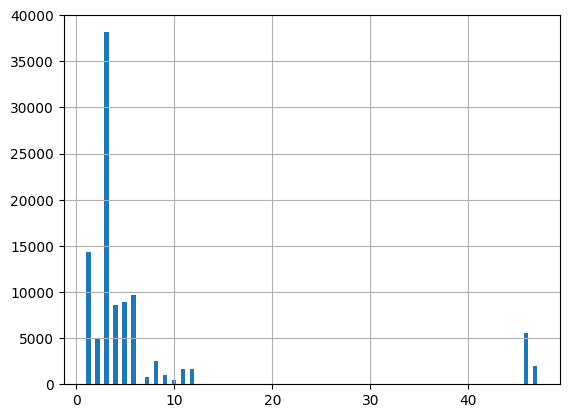

In [6]:
kinki['s_activity_type'].hist(bins=100)

In [28]:
kinki[kinki['household_person_no']==8000102]

,cities_code_x,household_person_no,trip_no,frequency,dep_pre_code,dep_zone_code,dep_cities_code,dep_pt_code,dep_pt_Mcode,dep_pt_Lcode,...,wagon_cnt,bus,motorcycles_cnt,scooter_cnt,bicycle_cnt,person_cnt,under5_person_cnt,in_area_flg_3,in_area_flg_4,expansion_factor2
85,25201,8000102,1,NaN,1,5200025,25201,11120,111,11,...,0,0,0,2,0,2,0,1.0,1.0,17
86,25201,8000102,2,NaN,2,5200025,25201,11120,111,11,...,0,0,0,2,0,2,0,1.0,1.0,17


### Assign individual files by demographics

In [26]:
path = '/mnt/large/data/PseudoPFLOW/ver2.0/Kinki_PT_2010/'


for pid, person in kinki.groupby('household_person_no'):

    gender, age, occupation = person['sex'].iloc[0], person['age'].iloc[0], person['s_work'].iloc[0]

    directory = ''

    if occupation in [13, 14]:
        directory = 'student1/' if age < 19 else 'student2/'
    elif occupation in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 21]:
        directory = 'labor_male/' if gender == 1 else 'labor_female/'
    else:
        if age > 65:
            directory = 'nolabor_male_senior/' if gender == 1 else 'nolabor_female_senior/'
        else:
            directory = 'nolabor_male/' if gender == 1 else 'nolabor_female/'
    
    # print(directory, uid)
    if not os.path.exists(f'{path}{directory}'): 
        os.makedirs(f'{path}{directory}')
    else:
        person.to_csv(f'{path}{directory}{pid}.csv', index=False)

### Temporal (15min) Activity Interpolation

In [78]:
def survey_time_to_datetime(hour, minute):
    if pd.isna(hour) or pd.isna(minute) or hour == 99 or minute == 99:
        return None
    hour, minute = int(hour), int(minute)
    if hour < 24:
        return datetime(2010, 11, 9, hour, minute)
    else:
        return datetime(2010, 11, 10, hour-24, minute)

# Define the mapping from activity numbers to their corresponding codes
activity_mapping = {str(key): value for key, value in {
    '1': '002', '2': '003', '3': '001', '4': '100', '5': '200', '6': '400',
    '7': '500', '8': '500', '9': '500', '10': '500', '11': '500', '12': '500',
    '47': '500', '46': '400', '0': '000'
}.items()}

In [31]:
def adjust_activity_for_overlapping_intervals_with_mapping(dataset):
    precise_activity_intervals = defaultdict(lambda: defaultdict(int))
    skip_file = False

    for _, trip in dataset.iterrows():
        try:
            purpose = str(int(trip['s_activity_type'])) if not pd.isna(trip['s_activity_type']) and trip['s_activity_type'] != 99 else "0"
            start_time = survey_time_to_datetime(trip['dep_hour'], trip['dep_minute'])
            end_time = survey_time_to_datetime(trip['arr_hour'], trip['arr_minute'])

            if start_time and end_time:
                current_time = start_time - timedelta(minutes=start_time.minute % 15)
                while current_time < end_time:
                    interval_end = current_time + timedelta(minutes=15)
                    overlap_start = max(current_time, start_time)
                    overlap_end = min(interval_end, end_time)
                    overlap_duration = (overlap_end - overlap_start).total_seconds() / 60
                    if overlap_duration > 0:
                        precise_activity_intervals[current_time.strftime('%H:%M')][purpose] += overlap_duration
                    current_time += timedelta(minutes=15)
        except KeyError:
            print(f"KeyError encountered in file. Skipping file: {file_path}")
            return None

    resolved_schedule = {}
    for time_point, activities in precise_activity_intervals.items():
        main_activity = max(activities, key=lambda k: (activities[k], k != '0')) if activities else '0'
        resolved_schedule[time_point] = activity_mapping.get(main_activity, '000')

    for h in range(24):
        for m in range(0, 60, 15):
            time_slot = f"{h:02d}:{m:02d}"
            if time_slot not in resolved_schedule:
                resolved_schedule[time_slot] = '000'
                
    if resolved_schedule['00:00'] == '000':
        resolved_schedule['00:00'] = '001'

    return dict(sorted(resolved_schedule.items(), key=lambda x: datetime.strptime(x[0], '%H:%M')))

In [32]:
source_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Kinki_PT_2010/"
target_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Kinki_PT_2010"

# Walk through the source directory
for root, dirs, files in os.walk(source_base_path):
    for file in files:
        if file == '.DS_Store':
            continue
        try: 
            file_path = os.path.join(root, file)
            data = pd.read_csv(file_path)
            final_schedule_with_mapping = adjust_activity_for_overlapping_intervals_with_mapping(data)

            if final_schedule_with_mapping is None:
                print(f"Skipped file due to '99': {file_path}")
                continue

            relative_path = os.path.relpath(root, source_base_path)
            target_dir = os.path.join(target_base_path, relative_path)
            if not os.path.exists(target_dir):
                os.makedirs(target_dir)
            target_file_path = os.path.join(target_dir, file)

            # Convert the schedule to a DataFrame and save as CSV
            pd.DataFrame.from_dict(final_schedule_with_mapping, orient='index', columns=['Activity']).to_csv(target_file_path, index_label='Time')
        except Exception as e:
            print(f"An error occurred while processing file {file_path}: {e}")
print("Processing completed.")

Processing completed.


### Time-dependent Markov Chain

In [33]:
def save_markov_chain(transition_probabilities, time_slots, states, output_file_path):
    with open(output_file_path, 'w') as f:
        for step, time_slot in enumerate(time_slots):  
            line = f"{step:03d},"
            for s1 in states[1:]:
                line = line + s1 + ' '
                for s2 in states:
                    line = line + s2 + ' ' + str(transition_probabilities[time_slot][states.index(s1)][states.index(s2)]) + ' '
                line += ','
            f.write(line.strip(' ,')+'\n')

In [34]:
states = ['000', '001', '002', '003', '100', '200', '300', '400', '500']
state_indices = {state: idx for idx, state in enumerate(states)}  
time_steps = [f"{h:02d}:{m:02d}" for h in range(24) for m in range(0, 60, 15)]

source_folder = '/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Kinki_PT_2010/'
target_folder = '/mnt/large/data/PseudoPFLOW/Processing/markov/'
dirs = ['student2', 'nolabor_male_senior', 'nolabor_female', 'nolabor_male', 'labor_male', 'nolabor_female_senior', 'student1', 'labor_female']

for folder in dirs:
    transition_counts_per_time_step = {time_step: np.zeros((len(states), len(states))) for time_step in time_steps}
    folder_path = os.path.join(source_folder, folder)
    
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):
            data = pd.read_csv(file_path, dtype={'Time': str, 'Activity': str})
            data.sort_values(by='Time', inplace=True)

            previous_state = None
            data_length = len(data) - 1
            for i in range(data_length):
                current_state, next_state, time_step = data.iloc[i]['Activity'], data.iloc[i + 1]['Activity'], data.iloc[i]['Time']
                if current_state != '000':
                    previous_state = current_state

                if previous_state in state_indices and next_state in state_indices:
                    if previous_state == next_state:
                        next_state = '000'
                    previous_index, next_index = state_indices[previous_state], state_indices[next_state]
                    transition_counts_per_time_step[time_step][previous_index, next_index] += 1

    transition_probabilities_per_time_step = {}
    for time_step, counts in transition_counts_per_time_step.items():
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1 
        probabilities = counts / row_sums
        transition_probabilities_per_time_step[time_step] = probabilities

    output_path = os.path.join(target_folder, f'kinki2010_trip_{folder}_prob.csv')
    save_markov_chain(transition_probabilities_per_time_step, time_steps, states, output_path)

## Chukyo 2011 PT Master

In [64]:
Chukyo = pd.read_csv('/mnt/large/data/00_PTData/02_ChukyoH23/10_rawdata/東京大学/第5回平日基本マスター_秘匿（東京大学）.csv', header=None)
Chukyo

,0,1,2,3,4,5,6,7,8,9,...,141,142,143,144,145,146,147,148,149,150
0,1,1,1,201,1,7,1,,,201,...,,,,,,,,,,NaN
1,1,1,1,201,1,9,1,,,201,...,,,,,,,22,,36,NaN
2,1,1,1,201,1,9,1,,,201,...,,,,,,,22,,27,NaN
3,1,1,1,201,1,9,1,,,201,...,,,,,,,22,,36,NaN
4,1,1,1,201,1,9,1,,,201,...,,,,,,,22,,22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628607,1,1,6,211,5,38950,2,,,133,...,,,,,,,8,,8,NaN
628608,1,1,6,211,5,38950,2,,,133,...,,,,,,,8,,8,NaN
628609,1,1,6,211,5,38954,1,,,133,...,,,,,,,13,,13,NaN
628610,1,1,6,211,5,38954,1,,,133,...,,,,,,,13,,13,NaN


In [75]:
path = '/mnt/large/data/PseudoPFLOW/ver2.0/Chukyo_PT_2011/'

for pid, person in kinki.groupby([4, 5, 6, 7]):

    uid = f'{pid[0]:04}{pid[1]}{pid[2]:05}{pid[2]:02}'
    print(uid)
   
    gender, age, occupation = person.iloc[:, 48].iloc[0], person.iloc[:, 49].iloc[0], person.iloc[:, 53].iloc[0]
    
    directory = ''

    if occupation == 9:
        if age < 19:
            directory = 'student1/' 
        else: 
            if age > 65:
                directory = 'nolabor_male_senior/' if gender == 1 else 'nolabor_female_senior/'
            else:
                directory = 'nolabor_male/' if gender == 1 else 'nolabor_female/'
    elif occupation in [1, 2, 3, 4, 5, 6]:
        directory = 'labor_male/' if gender == 1 else 'labor_female/'
    else:
        if age > 65:
            directory = 'nolabor_male_senior/' if gender == 1 else 'nolabor_female_senior/'
        else:
            directory = 'nolabor_male/' if gender == 1 else 'nolabor_female/'
    
    # print(directory, uid)
    if not os.path.exists(f'{path}{directory}'): 
        os.makedirs(f'{path}{directory}')
    else:
        person.to_csv(f'{path}{directory}{uid}.csv', index=False)

000110000101
000110000202
000110000303
000110000404
000110000505
000120000101
000120000202
000120000303
000120000404
000120000505
000120000606
000120000707
000130000101
000130000202
000130000303
000130000404
000130000505
000130000606
000140000101
000140000202
000140000303
000140000404
000140000505
000140000606
000150000101
000150000202
000150000303
000150000404
000150000505
000150000606
000150000707
000160000101
000160000202
000160000303
000160000404
000160000505
000160000606
000170000101
000170000202
000170000303
000170000404
000170000505
000170000606
000170000707
000170000808
000180000101
000180000202
000180000303
000180000404
000180000505
000180000606
000190000101
000190000202
000190000303
000190000404
000190000505
000190000606
000190000707
0001100000101
0001100000202
0001100000303
0001100000404
0001100000505
0001110000101
0001110000202
0001110000303
0001110000404
0001110000505
0001110000606
0001110000707
0001120000101
0001120000202
0001120000303
0001120000404
0001120000505
00011300

In [105]:
activity_mapping = {str(key): value for key, value in {
    '1': '002', '2': '003', '3': '001', '4': '002', '5': '100', '6': '100',
    '7': '300', '8': '400', '9': '200', '10': '400', '11': '400', '12': '400',
    '13': '400', '14': '400', '15': '400', '16': '400', '17': '500', '18': '500',
    '19': '500', '20': '500', '21': '500', '0': '000'
}.items()}

def survey_time_to_datetime(hour, minute):
    if pd.isna(hour) or pd.isna(minute) or hour == 99 or minute == 99:
        return None
    hour, minute = int(hour), int(minute)
    if hour < 24:
        return datetime(2010, 11, 9, hour, minute)
    else:
        return datetime(2010, 11, 10, hour-24, minute)

def adjust_activity_for_overlapping_intervals_with_mapping(dataset):
    precise_activity_intervals = defaultdict(lambda: defaultdict(int))
    skip_file = False

    for _, trip in dataset.iterrows():
        try:
            purpose = str(int(trip.iloc[104])) if not pd.isna(trip.iloc[104]) and trip.iloc[104] != 99 else "0"
            start_time = survey_time_to_datetime(trip.iloc[87], trip.iloc[88])
            end_time = survey_time_to_datetime(trip.iloc[102], trip.iloc[103])

            if start_time and end_time:
                current_time = start_time - timedelta(minutes=start_time.minute % 15)
                while current_time < end_time:
                    interval_end = current_time + timedelta(minutes=15)
                    overlap_start = max(current_time, start_time)
                    overlap_end = min(interval_end, end_time)
                    overlap_duration = (overlap_end - overlap_start).total_seconds() / 60
                    if overlap_duration > 0:
                        precise_activity_intervals[current_time.strftime('%H:%M')][purpose] += overlap_duration
                    current_time += timedelta(minutes=15)
        except KeyError:
            print(f"KeyError encountered in file. Skipping file: {file_path}")
            return None

    resolved_schedule = {}
    for time_point, activities in precise_activity_intervals.items():
        main_activity = max(activities, key=lambda k: (activities[k], k != '0')) if activities else '0'
        resolved_schedule[time_point] = activity_mapping.get(main_activity, '000')

    for h in range(24):
        for m in range(0, 60, 15):
            time_slot = f"{h:02d}:{m:02d}"
            if time_slot not in resolved_schedule:
                resolved_schedule[time_slot] = '000'
                
    if resolved_schedule['00:00'] == '000':
        resolved_schedule['00:00'] = '001'

    return dict(sorted(resolved_schedule.items(), key=lambda x: datetime.strptime(x[0], '%H:%M')))

In [116]:
source_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Chukyo_PT_2011/"
target_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011"

# Walk through the source directory
for root, dirs, files in os.walk(source_base_path):
    for file in files:
        if file == '.DS_Store':
            continue
        try: 
            file_path = os.path.join(root, file)
            data = pd.read_csv(file_path)
            final_schedule_with_mapping = adjust_activity_for_overlapping_intervals_with_mapping(data)

            if final_schedule_with_mapping is None:
                print(f"Skipped file due to '99': {file_path}")
                continue

            relative_path = os.path.relpath(root, source_base_path)
            target_dir = os.path.join(target_base_path, relative_path)
            if not os.path.exists(target_dir):
                os.makedirs(target_dir)
            target_file_path = os.path.join(target_dir, file)

            # Convert the schedule to a DataFrame and save as CSV
            pd.DataFrame.from_dict(final_schedule_with_mapping, orient='index', columns=['Activity']).to_csv(target_file_path, index_label='Time')
        except Exception as e:
            # print(f"An error occurred while processing file {file_path}: {e}")
            i = 0
print("Processing completed.")

Processing completed.


In [117]:
states = ['000', '001', '002', '003', '100', '200', '300', '400', '500']
state_indices = {state: idx for idx, state in enumerate(states)}  
time_steps = [f"{h:02d}:{m:02d}" for h in range(24) for m in range(0, 60, 15)]

source_folder = '/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/'
target_folder = '/mnt/large/data/PseudoPFLOW/Processing/markov/'
dirs = ['nolabor_male_senior', 'nolabor_female', 'nolabor_male', 'labor_male', 'nolabor_female_senior', 'student1', 'labor_female']

for folder in dirs:
    transition_counts_per_time_step = {time_step: np.zeros((len(states), len(states))) for time_step in time_steps}
    folder_path = os.path.join(source_folder, folder)
    print(folder_path)
    
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):
            data = pd.read_csv(file_path, dtype={'Time': str, 'Activity': str})
            data.sort_values(by='Time', inplace=True)

            previous_state = None
            data_length = len(data) - 1
            for i in range(data_length):
                current_state, next_state, time_step = data.iloc[i]['Activity'], data.iloc[i + 1]['Activity'], data.iloc[i]['Time']
                if current_state != '000':
                    previous_state = current_state

                if previous_state in state_indices and next_state in state_indices:
                    if previous_state == next_state:
                        next_state = '000'
                    previous_index, next_index = state_indices[previous_state], state_indices[next_state]
                    transition_counts_per_time_step[time_step][previous_index, next_index] += 1

    transition_probabilities_per_time_step = {}
    for time_step, counts in transition_counts_per_time_step.items():
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1 
        probabilities = counts / row_sums
        transition_probabilities_per_time_step[time_step] = probabilities

    output_path = os.path.join(target_folder, f'chukyo2011_trip_{folder}_prob.csv')
    save_markov_chain(transition_probabilities_per_time_step, time_steps, states, output_path)

/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/nolabor_male_senior
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/nolabor_female
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/nolabor_male
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/labor_male
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/nolabor_female_senior
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/student1
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Chukyo_PT_2011/labor_female


## Hokkaido PT Master 2006

In [89]:
hokkaido = pd.read_csv("/mnt/large/data/00_PTData/21_旭川H14/10_rawdata_H14(2002)/H14旭川圏ＰＴ平日マスター.csv", encoding='Shift-jis')
hokkaido

,市町村ＢＣＤ,バッチ,世帯,個人ＮＯ,性別,年齢,続柄,職業,産業,現住所,...,駐輪場種類,拡大係数１,拡大係数２,目的１,目的２,目的３,代表手段１,代表手段２,代表手段３,代表手段４
0,20401011,1,1,1,2,60,1,15,12,20401011,...,0,11,11,11,6,5,1,7,6,5
1,20401011,1,1,1,2,60,1,15,12,20401011,...,0,11,11,5,3,3,1,7,6,5
2,20401011,1,2,1,1,63,1,10,7,20401011,...,0,13,13,1,1,1,10,2,2,2
3,20401011,1,2,1,1,63,1,10,7,20401011,...,0,13,13,5,3,3,6,3,3,3
4,20401011,1,2,1,1,63,1,10,7,20401011,...,0,13,21,12,7,5,6,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62198,45800000,1,32,4,2,12,3,12,12,45800000,...,0,12,12,3,2,2,1,7,6,5
62199,45800000,1,32,4,2,12,3,12,12,45800000,...,0,12,12,5,3,3,1,7,6,5
62200,45800000,1,33,3,2,34,3,14,12,45800000,...,0,10,16,12,7,5,7,3,3,3
62201,45800000,1,33,3,2,34,3,14,12,45800000,...,0,10,16,18,8,5,7,3,3,3


In [93]:
path = '/mnt/large/data/PseudoPFLOW/ver2.0/Asahikawa_PT_2002/'

for pid, person in hokkaido.groupby(['市町村ＢＣＤ', 'バッチ', '世帯', '個人ＮＯ']):

    uid = f'{pid[0]:04}{pid[1]}{pid[2]:05}{pid[2]:02}'
   
    gender, age, occupation = person['性別'].iloc[0], person['年齢'].iloc[0], person['職業'].iloc[0]
    
    directory = ''

    if occupation == 12:
        directory = 'student1/'
    elif occupation == 13:
        directory = 'student2/'
    elif occupation in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]:
        directory = 'labor_male/' if gender == 1 else 'labor_female/'
    else:
        if age > 65:
            directory = 'nolabor_male_senior/' if gender == 1 else 'nolabor_female_senior/'
        else:
            directory = 'nolabor_male/' if gender == 1 else 'nolabor_female/'
    
    # print(directory, uid)
    if not os.path.exists(f'{path}{directory}'): 
        os.makedirs(f'{path}{directory}')
    else:
        person.to_csv(f'{path}{directory}{uid}.csv', index=False)

In [98]:
activity_mapping = {str(key): value for key, value in {
    '1': '002', '2': '002', '3': '003', '4': '003', '5': '001', '6': '500',
    '7': '500', '8': '500', '9': '500', '10': '500', '11': '100', '12': '400',
    '13': '002', '14': '002', '15': '003', '16': '003', '17': '500', '18': '400',
    '19': '001', '20': '400', '0': '000'
}.items()}

def survey_time_to_datetime(hour, minute, am_pm):
    if pd.isna(hour) or pd.isna(minute) or hour == 99 or minute == 99:
        return None
    hour, minute = int(hour), int(minute)
    if am_pm == 2 and hour < 12:
        hour += 12
    return datetime(2024, 1, 1, hour, minute)

def adjust_activity_for_overlapping_intervals_with_mapping(dataset):
    precise_activity_intervals = defaultdict(lambda: defaultdict(int))
    skip_file = False

    for _, trip in dataset.iterrows():
        try:
            purpose = str(int(trip['目的'])) if not pd.isna(trip['目的']) and trip['目的'] != 99 else "0"
            start_time = survey_time_to_datetime(trip['出発（時）'], trip['出発（分）'], trip['出発午前午後'])
            end_time = survey_time_to_datetime(trip['到着（時）'], trip['到着（分）'], trip['到着午前午後'])

            if start_time and end_time:
                current_time = start_time - timedelta(minutes=start_time.minute % 15)
                while current_time < end_time:
                    interval_end = current_time + timedelta(minutes=15)
                    overlap_start = max(current_time, start_time)
                    overlap_end = min(interval_end, end_time)
                    overlap_duration = (overlap_end - overlap_start).total_seconds() / 60
                    if overlap_duration > 0:
                        precise_activity_intervals[current_time.strftime('%H:%M')][purpose] += overlap_duration
                    current_time += timedelta(minutes=15)
        except KeyError:
            print(f"KeyError encountered in file. Skipping file: {file_path}")
            return None

    resolved_schedule = {}
    for time_point, activities in precise_activity_intervals.items():
        main_activity = max(activities, key=lambda k: (activities[k], k != '0')) if activities else '0'
        resolved_schedule[time_point] = activity_mapping.get(main_activity, '000')

    for h in range(24):
        for m in range(0, 60, 15):
            time_slot = f"{h:02d}:{m:02d}"
            if time_slot not in resolved_schedule:
                resolved_schedule[time_slot] = '000'
                
    if resolved_schedule['00:00'] == '000':
        resolved_schedule['00:00'] = '001'

    return dict(sorted(resolved_schedule.items(), key=lambda x: datetime.strptime(x[0], '%H:%M')))

In [99]:
source_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Asahikawa_PT_2002/"
target_base_path = "/mnt/large/data/PseudoPFLOW/ver2.0/Markov/"

# Walk through the source directory
for root, dirs, files in os.walk(source_base_path):
    for file in files:
        if file == '.DS_Store':
            continue
        try: 
            file_path = os.path.join(root, file)
            data = pd.read_csv(file_path)
            final_schedule_with_mapping = adjust_activity_for_overlapping_intervals_with_mapping(data)

            if final_schedule_with_mapping is None:
                print(f"Skipped file due to '99': {file_path}")
                continue

            relative_path = os.path.relpath(root, source_base_path)
            target_dir = os.path.join(target_base_path, relative_path)
            if not os.path.exists(target_dir):
                os.makedirs(target_dir)
            target_file_path = os.path.join(target_dir, file)

            # Convert the schedule to a DataFrame and save as CSV
            pd.DataFrame.from_dict(final_schedule_with_mapping, orient='index', columns=['Activity']).to_csv(target_file_path, index_label='Time')
        except Exception as e:
            print(f"An error occurred while processing file {file_path}: {e}")
print("Processing completed.")

Processing completed.


In [103]:
states = ['000', '001', '002', '003', '100', '200', '300', '400', '500']
state_indices = {state: idx for idx, state in enumerate(states)}  
time_steps = [f"{h:02d}:{m:02d}" for h in range(24) for m in range(0, 60, 15)]

source_folder = '/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/'
target_folder = '/mnt/large/data/PseudoPFLOW/Processing/markov/'
dirs = ['nolabor_male_senior', 'nolabor_female', 'nolabor_male', 'labor_male', 'nolabor_female_senior', 'student1', 'student2', 'labor_female']

for folder in dirs:
    transition_counts_per_time_step = {time_step: np.zeros((len(states), len(states))) for time_step in time_steps}
    folder_path = os.path.join(source_folder, folder)
    print(folder_path)
    
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):
            data = pd.read_csv(file_path, dtype={'Time': str, 'Activity': str})
            data.sort_values(by='Time', inplace=True)

            previous_state = None
            data_length = len(data) - 1
            for i in range(data_length):
                current_state, next_state, time_step = data.iloc[i]['Activity'], data.iloc[i + 1]['Activity'], data.iloc[i]['Time']
                if current_state != '000':
                    previous_state = current_state

                if previous_state in state_indices and next_state in state_indices:
                    if previous_state == next_state:
                        next_state = '000'
                    previous_index, next_index = state_indices[previous_state], state_indices[next_state]
                    transition_counts_per_time_step[time_step][previous_index, next_index] += 1

    transition_probabilities_per_time_step = {}
    for time_step, counts in transition_counts_per_time_step.items():
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1 
        probabilities = counts / row_sums
        transition_probabilities_per_time_step[time_step] = probabilities

    output_path = os.path.join(target_folder, f'Asahikawa2002_trip_{folder}_prob.csv')
    save_markov_chain(transition_probabilities_per_time_step, time_steps, states, output_path)

/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/nolabor_male_senior
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/nolabor_female
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/nolabor_male
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/labor_male
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/nolabor_female_senior
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/student1
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/student2
/mnt/large/data/PseudoPFLOW/ver2.0/Markov/Asahikawa_PT_2002/labor_female


## Kyushu 2005